# COSC2671 / COSC3047 — Social Media and Network Analytics — Assignment 2

## Hubs, Bridges & Climate Discourse: Analysing User Interaction and Community Structure in Reddit Climate Discussions

**Dataset:** `cathw/reddit_climate_comment` (HuggingFace, MIT Licence)  
**Collected:** 21–22 February 2024 using Reddit API / PRAW  
**Subreddits:** `climate`, `climatechange`, `energy`, `environment`, `renewableenergy`, `sustainability`, `climateactionplan`, `zerowaste`

### Research Question
How do Reddit users interact in climate change discussions, and which users, topics, and subreddit communities act as hubs or bridges in the climate discourse network?

### Notebook Structure
1. Setup and imports  
2. Helper functions  
3. Load dataset  
4. Flatten comments and replies  
5. Filter deleted, bot, and self-loop edges  
6. Create submission CSV sample  
7. Dataset overview  
8. Sentiment analysis using VADER  
9. Kruskal–Wallis test and TF-IDF keywords  
10. LDA topic modelling  
11. Topic labels  
12. Directed user interaction network  
13. Centrality analysis: PageRank and approximate bridge score  
14. Community detection  
15. Network visualisation  
16. Bipartite subreddit-topic network  
17. Subreddit similarity network  
18. Save final results  
19. Network summary


## 1. Setup and Imports

This section imports the core packages for file handling, data processing, and basic visualisation. Specialist NLP, topic modelling, statistical testing, and network analysis packages are imported in the sections where they are used.


In [1]:
# ============================================================
# COSC2671 / SMNA Assignment 2
# Reddit Climate Comments: NLP + Network Analysis
# ============================================================

import os
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
print("Core imports done.")

Core imports done.


In [2]:
# ------------------------------------------------------------
# BASIC SETTINGS
# ------------------------------------------------------------

INPUT_FILE  = "comment.parquet"
OUTPUT_DIR  = "assignment2_final_outputs"
MAX_SAMPLE_MB = 9.5
RANDOM_SEED   = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Output folder ready:", OUTPUT_DIR)

Output folder ready: assignment2_final_outputs


## 2. Helper Functions

This section defines reusable functions for handling nested parquet data, cleaning Reddit text, labelling sentiment scores, saving a sample under the 10 MB limit, and displaying tables.


In [3]:
# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------

def make_list(value):
    """Converts nested parquet objects into normal Python lists."""
    if value is None:
        return []
    if isinstance(value, list):
        return value
    if isinstance(value, np.ndarray):
        return value.tolist()
    try:
        return list(value)
    except TypeError:
        return [value]


def clean_reddit_text(text):
    """
    Cleans Reddit text for NLP analysis.
    Steps: remove URLs, HTML entities, user/subreddit mentions,
    non-alphanumeric characters, and excess whitespace.
    """
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"&amp;", "and", text)
    text = re.sub(r"u\/[A-Za-z0-9_-]+", " ", text)
    text = re.sub(r"r\/[A-Za-z0-9_-]+", " ", text)
    text = re.sub(r"[^A-Za-z0-9#@'\-\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def get_sentiment_label(score):
    """VADER compound score thresholds (Hutto & Gilbert, 2014)."""
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"


def save_under_size_limit(df, path, limit_mb=9.5, seed=42):
    """Saves a CSV file, reducing row count until it is under limit_mb."""
    temp = df.copy()
    while True:
        temp.to_csv(path, index=False, encoding="utf-8")
        size_mb = os.path.getsize(path) / (1024 * 1024)
        if size_mb <= limit_mb:
            return temp, size_mb
        new_n = int(len(temp) * 0.90)
        temp = temp.sample(n=new_n, random_state=seed)


def get_vectorizer_words(vectorizer):
    """Handles both old and new scikit-learn API versions."""
    if hasattr(vectorizer, "get_feature_names_out"):
        return np.array(vectorizer.get_feature_names_out())
    return np.array(vectorizer.get_feature_names())


def safe_display(df, n=10):
    """Displays dataframe in Jupyter or prints as fallback."""
    try:
        display(df.head(n))
    except NameError:
        print(df.head(n))


print("Helper functions defined.")

Helper functions defined.


## 3. Load Dataset

This section loads the Reddit climate dataset from a `.parquet` file. The dataset contains posts, comments, replies, author fields, subreddit labels, timestamps, and text content, which makes it suitable for both NLP and directed network analysis.


In [4]:
# ------------------------------------------------------------
# LOAD DATASET
# ------------------------------------------------------------

import glob

# Search notebook folder first, then common local folders used during development.
possible_files = []
possible_files.extend(glob.glob("*.parquet"))
possible_files.extend(glob.glob(os.path.join(os.path.expanduser("~"), "Downloads", "*.parquet")))
possible_files.extend(glob.glob(os.path.join(os.path.expanduser("~"), "Desktop", "*.parquet")))
possible_files = list(dict.fromkeys(possible_files))

print(f"Parquet file search completed. Files found: {len(possible_files)}")

# Prefer the expected dataset filename.
if os.path.exists("comment.parquet"):
    selected_file = "comment.parquet"
elif os.path.exists("comment(2).parquet"):
    selected_file = "comment(2).parquet"
else:
    matching = [f for f in possible_files if "comment" in os.path.basename(f).lower()]
    if matching:
        selected_file = matching[0]
    elif possible_files:
        selected_file = possible_files[0]
    else:
        raise FileNotFoundError("No .parquet file found. Place comment.parquet in this folder.")

print("Using selected parquet file.")

try:
    raw_df = pd.read_parquet(selected_file)
except Exception:
    import pyarrow.parquet as pq
    raw_df = pq.read_table(selected_file).to_pandas()

print("Raw dataset shape:", raw_df.shape)
print("Columns:", list(raw_df.columns))

Parquet file search completed. Files found: 2
Using selected parquet file.
Raw dataset shape: (6550, 11)
Columns: ['id', 'post_title', 'post_author', 'post_body', 'post_url', 'post_pic', 'subreddit', 'post_timestamp', 'post_upvotes', 'post_permalink', 'comments']


## 4. Flatten Comments and Replies

The parquet file stores posts with nested comments and replies. This section flattens the nested structure into one row per comment or reply while keeping post metadata such as subreddit, post title, and post author.

An edge list is also created for the user interaction network. A directed edge `A → B` means user A commented on user B's post or replied to user B's comment.


In [5]:
# ------------------------------------------------------------
# FLATTEN POSTS, COMMENTS AND REPLIES
# ------------------------------------------------------------

records      = []
edge_records = []

for _, post in raw_df.iterrows():

    post_id     = post.get("id")
    post_author = post.get("post_author")
    post_title  = post.get("post_title")
    post_body   = post.get("post_body")
    subreddit   = post.get("subreddit")
    post_time   = post.get("post_timestamp")
    post_upvotes = post.get("post_upvotes")
    post_permalink = post.get("post_permalink")
    comments_obj   = post.get("comments")

    if not isinstance(comments_obj, dict):
        continue

    comment_authors  = make_list(comments_obj.get("CommentAuthor"))
    comment_bodies   = make_list(comments_obj.get("CommentBody"))
    comment_ids      = make_list(comments_obj.get("CommentID"))
    comment_times    = make_list(comments_obj.get("CommentTimestamp"))
    comment_upvotes  = make_list(comments_obj.get("CommentUpvotes"))
    reply_groups     = make_list(comments_obj.get("replies"))

    comment_count = max(len(comment_authors), len(comment_bodies),
                        len(comment_ids), len(comment_times), len(comment_upvotes))

    for i in range(comment_count):
        comment_id     = comment_ids[i]     if i < len(comment_ids)     else None
        comment_author = comment_authors[i] if i < len(comment_authors) else None
        comment_text   = comment_bodies[i]  if i < len(comment_bodies)  else ""
        comment_time   = comment_times[i]   if i < len(comment_times)   else None
        comment_score  = comment_upvotes[i] if i < len(comment_upvotes) else None

        records.append({
            "post_id": post_id, "subreddit": subreddit,
            "post_title": post_title, "post_body": post_body,
            "post_author": post_author, "post_timestamp": post_time,
            "post_upvotes": post_upvotes, "post_permalink": post_permalink,
            "message_id": comment_id, "message_type": "comment",
            "author": comment_author, "text": comment_text,
            "timestamp": comment_time, "upvotes": comment_score,
            "parent_id": post_id, "parent_author": post_author
        })

        if post_author is not None and comment_author is not None:
            edge_records.append({
                "source": comment_author, "target": post_author,
                "interaction_type": "comment_to_post_author", "subreddit": subreddit
            })

        if i < len(reply_groups) and isinstance(reply_groups[i], dict):
            r = reply_groups[i]
            reply_authors  = make_list(r.get("ReplyAuthor"))
            reply_bodies   = make_list(r.get("ReplyBody"))
            reply_ids      = make_list(r.get("ReplyID"))
            reply_times    = make_list(r.get("ReplyTimestamp"))
            reply_upvotes2 = make_list(r.get("ReplyUpvotes"))
            reply_count    = max(len(reply_authors), len(reply_bodies),
                                 len(reply_ids), len(reply_times), len(reply_upvotes2))

            for j in range(reply_count):
                reply_id     = reply_ids[j]     if j < len(reply_ids)     else None
                reply_author = reply_authors[j]  if j < len(reply_authors)  else None
                reply_text   = reply_bodies[j]   if j < len(reply_bodies)   else ""
                reply_time   = reply_times[j]    if j < len(reply_times)    else None
                reply_score  = reply_upvotes2[j] if j < len(reply_upvotes2) else None

                records.append({
                    "post_id": post_id, "subreddit": subreddit,
                    "post_title": post_title, "post_body": post_body,
                    "post_author": post_author, "post_timestamp": post_time,
                    "post_upvotes": post_upvotes, "post_permalink": post_permalink,
                    "message_id": reply_id, "message_type": "reply",
                    "author": reply_author, "text": reply_text,
                    "timestamp": reply_time, "upvotes": reply_score,
                    "parent_id": comment_id, "parent_author": comment_author
                })

                if comment_author is not None and reply_author is not None:
                    edge_records.append({
                        "source": reply_author, "target": comment_author,
                        "interaction_type": "reply_to_comment_author", "subreddit": subreddit
                    })

df        = pd.DataFrame(records)
edges_raw = pd.DataFrame(edge_records)

df["text"]       = df["text"].fillna("").astype(str)
df["clean_text"] = df["text"].apply(clean_reddit_text)

df = df[
    (df["message_id"].notna()) &
    (df["author"].notna()) &
    (df["clean_text"].str.len() > 2)
].drop_duplicates("message_id")

df["timestamp"]      = pd.to_datetime(df["timestamp"],      errors="coerce")
df["post_timestamp"] = pd.to_datetime(df["post_timestamp"], errors="coerce")
df["upvotes"]        = pd.to_numeric(df["upvotes"],      errors="coerce").fillna(0)
df["post_upvotes"]   = pd.to_numeric(df["post_upvotes"], errors="coerce").fillna(0)
df["word_count"]     = df["clean_text"].str.split().str.len()

print("Flattened text dataset shape:", df.shape)
print("Raw edge records:", edges_raw.shape)
safe_display(df)

Flattened text dataset shape: (96328, 18)
Raw edge records: (83518, 4)


,post_id,subreddit,post_title,post_body,post_author,post_timestamp,post_upvotes,post_permalink,message_id,message_type,author,text,timestamp,upvotes,parent_id,parent_author,clean_text,word_count
0,1001ghj,climate,"“The entire world is in trouble, and it’s weir...",None,Keith_McNeill65,2022-12-31 19:19:00,698,/r/climate/comments/1001ghj/the_entire_world_i...,j2f9s26,comment,just-cuz-i,“Climate change is so bad that an entire lake ...,2022-12-31 21:01:00,115,1001ghj,Keith_McNeill65,Climate change is so bad that an entire lake i...,37
1,1001ghj,climate,"“The entire world is in trouble, and it’s weir...",None,Keith_McNeill65,2022-12-31 19:19:00,698,/r/climate/comments/1001ghj/the_entire_world_i...,j2fofz2,reply,DatFatBear,"Climate change is a crime, a crime against hum...",2022-12-31 22:49:00,47,j2f9s26,just-cuz-i,Climate change is a crime a crime against huma...,9
2,10036hv,sustainability,New York Approves Human Composting Law,None,wewewawa,2022-12-31 20:42:00,314,/r/sustainability/comments/10036hv/new_york_ap...,j2f7408,comment,wewewawa,"For Fischer, this alternative, green method of...",2022-12-31 20:42:00,6,10036hv,wewewawa,For Fischer this alternative green method of b...,27
3,10036hv,sustainability,New York Approves Human Composting Law,None,wewewawa,2022-12-31 20:42:00,314,/r/sustainability/comments/10036hv/new_york_ap...,j2fzm1p,reply,rocketshipray,That's a pretty simple process. :),2023-01-01 00:14:00,7,j2f7408,wewewawa,That's a pretty simple process,5
4,1006cei,environment,High-efficiency water filter removes 99.9% of ...,None,WashingtonPass,2022-12-31 23:19:00,3656,/r/environment/comments/1006cei/highefficiency...,j2gghl5,comment,newt_37,Great. How do we get it to scale and help our ...,2023-01-01 02:25:00,432,1006cei,WashingtonPass,Great How do we get it to scale and help our n...,17
5,1006cei,environment,High-efficiency water filter removes 99.9% of ...,None,WashingtonPass,2022-12-31 23:19:00,3656,/r/environment/comments/1006cei/highefficiency...,j2gk4b2,reply,Groovyjoker,This is truly interesting. Should this technol...,2023-01-01 02:56:00,138,j2gghl5,newt_37,This is truly interesting Should this technolo...,23
6,1006cei,environment,High-efficiency water filter removes 99.9% of ...,None,WashingtonPass,2022-12-31 23:19:00,3656,/r/environment/comments/1006cei/highefficiency...,j2hdtku,reply,dumnezero,It's going to be necessary at water treatment ...,2023-01-01 08:12:00,39,j2gghl5,newt_37,It's going to be necessary at water treatment ...,9
7,1006cei,environment,High-efficiency water filter removes 99.9% of ...,None,WashingtonPass,2022-12-31 23:19:00,3656,/r/environment/comments/1006cei/highefficiency...,j2go03n,reply,DweEbLez0,"Oh that’s easy! But first, they must charge an...",2023-01-01 03:31:00,61,j2gghl5,newt_37,Oh that s easy But first they must charge an a...,32
8,1006cei,environment,High-efficiency water filter removes 99.9% of ...,None,WashingtonPass,2022-12-31 23:19:00,3656,/r/environment/comments/1006cei/highefficiency...,j2hjkk5,reply,adalast,I am assuming that you mean to filter the plas...,2023-01-01 09:38:00,25,j2gghl5,newt_37,I am assuming that you mean to filter the plas...,148
9,1006cei,environment,High-efficiency water filter removes 99.9% of ...,None,WashingtonPass,2022-12-31 23:19:00,3656,/r/environment/comments/1006cei/highefficiency...,j2hmj5b,reply,VersatileFaerie,"I think the big problem would be more so, ""how...",2023-01-01 10:24:00,11,j2gghl5,newt_37,I think the big problem would be more so how d...,140


## 5. Filter Deleted, Bot, and Self-loop Edges

This section removes invalid network edges involving deleted users, AutoModerator, missing usernames, and self-loops. This produces a cleaner edge list for network construction.


In [6]:
# ------------------------------------------------------------
# FILTER DELETED / BOT USERS
# ------------------------------------------------------------

bad_users = {"[deleted]", "deleted", "AutoModerator", "automoderator", "None", ""}

before_edges = len(edges_raw)

edges_raw["source"] = edges_raw["source"].fillna("").astype(str)
edges_raw["target"] = edges_raw["target"].fillna("").astype(str)

edges_clean = edges_raw[
    (~edges_raw["source"].isin(bad_users)) &
    (~edges_raw["target"].isin(bad_users)) &
    (edges_raw["source"] != edges_raw["target"])
].copy()

after_edges = len(edges_clean)
print(f"Removed {before_edges - after_edges} deleted/bot/self-loop edge records.")
print("Clean edge records:", after_edges)

Removed 728 deleted/bot/self-loop edge records.
Clean edge records: 82790


## 6. Create Submission CSV Sample

The full dataset is larger than the 10 MB submission limit. This section creates a stratified sample by subreddit and message type and saves it under 9.5 MB.


In [7]:
# ------------------------------------------------------------
# CREATE CSV SAMPLE UNDER 10 MB
# ------------------------------------------------------------

sample_target_rows = 18000
sample_parts = []

for (subreddit, message_type), group in df.groupby(["subreddit", "message_type"], dropna=False):
    share  = len(group) / len(df)
    take_n = max(50, int(share * sample_target_rows))
    take_n = min(take_n, len(group))
    sample_parts.append(group.sample(n=take_n, random_state=RANDOM_SEED))

sample_df   = pd.concat(sample_parts).drop_duplicates("message_id")
sample_path = os.path.join(OUTPUT_DIR, "reddit_climate_comments_sample_under10mb.csv")
sample_df, sample_size_mb = save_under_size_limit(sample_df, sample_path,
                                                   limit_mb=MAX_SAMPLE_MB, seed=RANDOM_SEED)

print("Dataset sample saved:", sample_path)
print("Rows:", len(sample_df))
print("Size:", round(sample_size_mb, 2), "MB")

Dataset sample saved: assignment2_final_outputs\reddit_climate_comments_sample_under10mb.csv
Rows: 10620
Size: 8.83 MB


## 7. Dataset Overview

This section summarises the cleaned dataset by subreddit, message type, and author activity. These checks confirm that the dataset contains enough text and interaction data for the assignment analysis.


Subreddit summary:


,subreddit,message_count
0,environment,29878
1,energy,18831
2,zerowaste,15829
3,climatechange,10032
4,climate,9922
5,sustainability,6213
6,climateactionplan,3269
7,renewableenergy,2354



Message type summary:


,message_type,message_count
0,reply,69462
1,comment,26866



Top 10 most active authors:


,author,message_count
0,mafco,881
1,silence7,265
2,ILikeNeurons,224
3,Splenda,193
4,mutatron,187
5,Tpaine63,133
6,fungussa,126
7,Speculawyer,126
8,FANGO,125
9,Ericus1,125


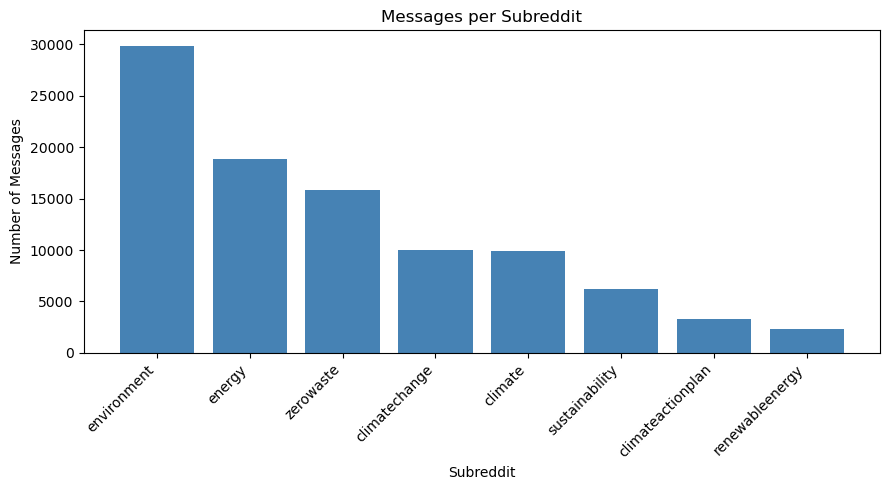

In [8]:
# ------------------------------------------------------------
# BASIC DATASET SUMMARIES
# ------------------------------------------------------------

subreddit_summary = (
    df["subreddit"].value_counts()
    .rename_axis("subreddit").reset_index(name="message_count")
)

message_type_summary = (
    df["message_type"].value_counts()
    .rename_axis("message_type").reset_index(name="message_count")
)

top_authors = (
    df["author"].value_counts().head(30)
    .rename_axis("author").reset_index(name="message_count")
)

subreddit_summary.to_csv(os.path.join(OUTPUT_DIR, "table_subreddit_summary.csv"), index=False)
message_type_summary.to_csv(os.path.join(OUTPUT_DIR, "table_message_type_summary.csv"), index=False)
top_authors.to_csv(os.path.join(OUTPUT_DIR, "table_top_authors.csv"), index=False)

print("Subreddit summary:")
safe_display(subreddit_summary)

print("\nMessage type summary:")
safe_display(message_type_summary)

print("\nTop 10 most active authors:")
safe_display(top_authors)

plt.figure(figsize=(9, 5))
plt.bar(subreddit_summary["subreddit"], subreddit_summary["message_count"],
        color="steelblue")
plt.title("Messages per Subreddit")
plt.xlabel("Subreddit")
plt.ylabel("Number of Messages")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_top_subreddits.png"), dpi=200)
plt.show()

## 8. Sentiment Analysis using VADER

This section applies VADER sentiment analysis to classify each Reddit message as positive, negative, or neutral. VADER is suitable for social media text because it works without labelled training data and uses standard compound-score thresholds.


Overall sentiment distribution:


,sentiment,message_count
0,positive,44771
1,negative,31545
2,neutral,20012



Sentiment mean by subreddit (sorted lowest to highest mean score):


,subreddit,count,mean,median,std
4,environment,29878,0.016480,0.00000,0.517132
2,climatechange,10032,0.019239,0.00000,0.512143
0,climate,9922,0.036670,0.00000,0.508631
3,energy,18831,0.102352,0.00000,0.499902
6,sustainability,6213,0.166943,0.15310,0.514058
5,renewableenergy,2354,0.181405,0.15395,0.477718
1,climateactionplan,3269,0.195785,0.22350,0.500694
7,zerowaste,15829,0.202742,0.20230,0.485288


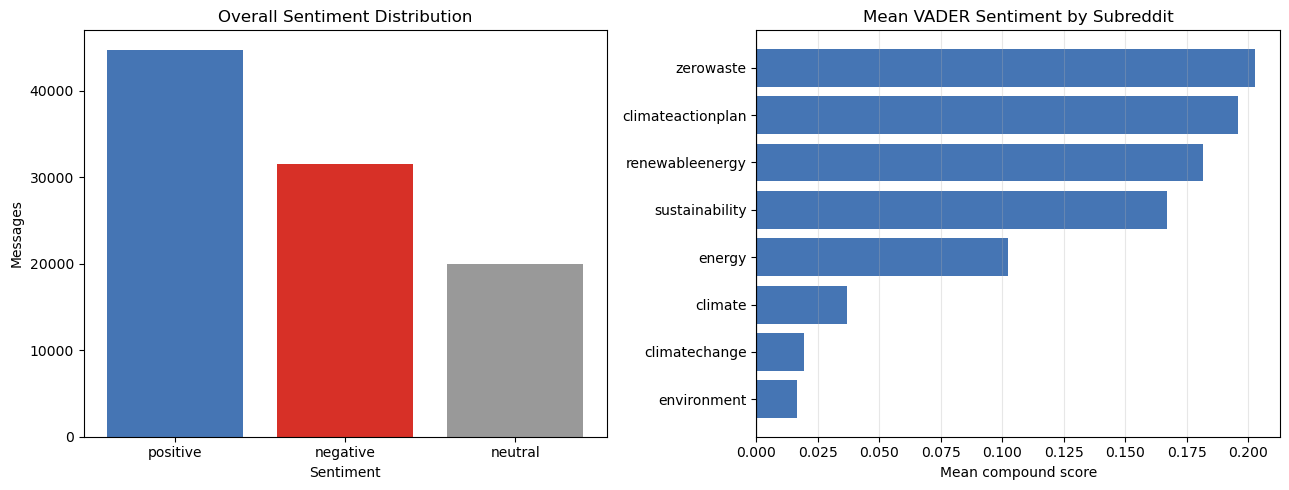


Interpretation: Solution-focused communities (zerowaste, climateactionplan, renewableenergy)
show stronger positive sentiment. Science/crisis communities (environment, climatechange) show lower mean sentiment.
This reflects how framing affects emotional tone in climate discourse.


In [9]:
# ------------------------------------------------------------
# SENTIMENT ANALYSIS USING VADER
# ------------------------------------------------------------

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

try:
    vader = SentimentIntensityAnalyzer()
except LookupError:
    nltk.download("vader_lexicon")
    vader = SentimentIntensityAnalyzer()

df["vader_compound"]  = df["clean_text"].apply(
    lambda t: vader.polarity_scores(t)["compound"]
)
df["sentiment_label"] = df["vader_compound"].apply(get_sentiment_label)

sentiment_overall = (
    df["sentiment_label"].value_counts()
    .rename_axis("sentiment").reset_index(name="message_count")
)

sentiment_mean_subreddit = (
    df.groupby("subreddit")["vader_compound"]
    .agg(["count", "mean", "median", "std"])
    .reset_index().sort_values("mean")
)

sentiment_overall.to_csv(os.path.join(OUTPUT_DIR, "table_sentiment_overall.csv"), index=False)
sentiment_mean_subreddit.to_csv(os.path.join(OUTPUT_DIR, "table_sentiment_mean_by_subreddit.csv"), index=False)

print("Overall sentiment distribution:")
safe_display(sentiment_overall)

print("\nSentiment mean by subreddit (sorted lowest to highest mean score):")
safe_display(sentiment_mean_subreddit)

# Plot 1: overall distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(sentiment_overall["sentiment"], sentiment_overall["message_count"],
            color=["#4575b4","#d73027","#999999"])
axes[0].set_title("Overall Sentiment Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Messages")

# Plot 2: mean sentiment per subreddit
colors = ["#d73027" if v < 0 else "#4575b4" for v in sentiment_mean_subreddit["mean"]]
axes[1].barh(sentiment_mean_subreddit["subreddit"], sentiment_mean_subreddit["mean"], color=colors)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Mean VADER Sentiment by Subreddit")
axes[1].set_xlabel("Mean compound score")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_sentiment.png"), dpi=200)
plt.show()

print("\nInterpretation: Solution-focused communities (zerowaste, climateactionplan, renewableenergy)")
print("show stronger positive sentiment. Science/crisis communities (environment, climatechange) show lower mean sentiment.")
print("This reflects how framing affects emotional tone in climate discourse.")

## 9. Kruskal–Wallis Test and TF-IDF Keywords

This section tests whether sentiment differs significantly across subreddits using the Kruskal–Wallis test. It also uses TF-IDF to identify vocabulary that is especially important within each subreddit compared with the rest of the corpus.


In [10]:
# ------------------------------------------------------------
# KRUSKAL-WALLIS SENTIMENT TEST
# ------------------------------------------------------------

from scipy import stats

sentiment_groups = [
    group["vader_compound"].dropna().values
    for _, group in df.groupby("subreddit")
    if len(group) >= 30
]

if len(sentiment_groups) >= 2:
    kruskal_stat, kruskal_p = stats.kruskal(*sentiment_groups)
    sentiment_test = pd.DataFrame([{
        "test": "Kruskal-Wallis",
        "statistic": round(kruskal_stat, 4),
        "p_value": kruskal_p,
        "significant": kruskal_p < 0.05,
        "interpretation": "Sentiment distributions differ significantly across subreddits (p<0.05)"
        if kruskal_p < 0.05 else "No significant difference"
    }])
    sentiment_test.to_csv(os.path.join(OUTPUT_DIR, "table_kruskal_sentiment_test.csv"), index=False)
    print("Kruskal-Wallis sentiment comparison test:")
    safe_display(sentiment_test)
else:
    print("Not enough subreddit groups.")


# ------------------------------------------------------------
# TF-IDF TERMS BY SUBREDDIT
# ------------------------------------------------------------

from sklearn.feature_extraction.text import TfidfVectorizer

subreddit_docs = (
    df.groupby("subreddit")["clean_text"]
    .apply(lambda texts: " ".join(texts))
    .reset_index()
)

tfidf_subreddit = TfidfVectorizer(
    stop_words="english", min_df=1, max_df=0.90,
    ngram_range=(1, 2), max_features=5000
)

subreddit_matrix = tfidf_subreddit.fit_transform(subreddit_docs["clean_text"])
subreddit_terms  = get_vectorizer_words(tfidf_subreddit)

tfidf_rows = []
for i, subreddit in enumerate(subreddit_docs["subreddit"]):
    row_values = subreddit_matrix[i].toarray().ravel()
    top_ids    = row_values.argsort()[-12:][::-1]
    tfidf_rows.append({
        "subreddit": subreddit,
        "top_tfidf_terms": ", ".join(subreddit_terms[top_ids])
    })

tfidf_table = pd.DataFrame(tfidf_rows)
tfidf_table.to_csv(os.path.join(OUTPUT_DIR, "table_tfidf_terms_by_subreddit.csv"), index=False)
print("\nTop TF-IDF terms by subreddit (community-specific vocabulary):")
safe_display(tfidf_table)

Kruskal-Wallis sentiment comparison test:


,test,statistic,p_value,significant,interpretation
0,Kruskal-Wallis,1984.436,0.0,True,Sentiment distributions differ significantly a...



Top TF-IDF terms by subreddit (community-specific vocabulary):


,subreddit,top_tfidf_terms
0,climate,"questions concerns, message compose, subreddit..."
1,climateactionplan,"forest, evs, nuclear power, plant based, olivi..."
2,climatechange,"warmer, sea level, ice age, glaciers, level ri..."
3,energy,"evs, heat pump, solar wind, nuclear power, inf..."
4,environment,"vegan, obama, fucked, vegetarian, bags, forest..."
5,renewableenergy,"evs, gw, mwh, wind turbines, solar wind, mw, e..."
6,sustainability,"vegan, plant based, bags, protein, clothes, pa..."
7,zerowaste,"bags, zero waste, reusable, bag, bottles, cup,..."


## 10. LDA Topic Modelling

This section applies LDA topic modelling to identify hidden themes in Reddit climate discussions. A perplexity sweep compares several topic counts. Although `k=8` has the lowest perplexity in this run, `k=6` is selected for the final model because it gives a smaller and more interpretable set of topic groups for the report.


Document-term matrix: 30,000 docs x 6,000 terms

LDA perplexity sweep (lower perplexity = better generalisation):


,number_of_topics,perplexity,log_likelihood
0,4,2361.54,-4393722.0
1,5,2373.73,-4396634.0
2,6,2360.40,-4393449.0
3,7,2302.09,-4379300.0
4,8,2298.83,-4378498.0
5,10,2353.27,-4391737.0


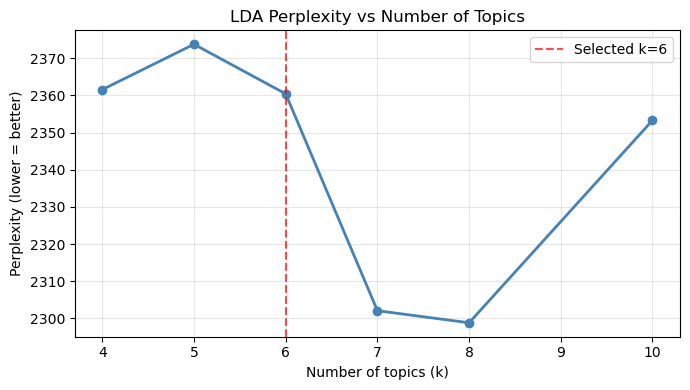


Selected k=6: balances perplexity and topic interpretability.
Note: k=8 has the lowest perplexity in this run.
k=6 is selected because it provides a smaller and more interpretable set of topics for the report.

Raw LDA topic top words:


,topic_id,top_words
0,0,"energy, solar, power, nuclear, wind, coal, gri..."
1,1,"water, just, like, heat, waste, don, use, make..."
2,2,"gas, oil, carbon, emissions, fossil, years, fu..."
3,3,"use, plastic, like, just, ve, don, really, car..."
4,4,"people, like, don, just, meat, think, food, ea..."
5,5,"climate, change, people, climate change, just,..."


In [11]:
# ------------------------------------------------------------
# LDA TOPIC MODELLING + PERPLEXITY SWEEP
# ------------------------------------------------------------

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

topic_df = df[df["word_count"] >= 5].copy()
if len(topic_df) > 30000:
    topic_df = topic_df.sample(n=30000, random_state=RANDOM_SEED)

count_vectorizer = CountVectorizer(
    lowercase=True, stop_words="english",
    min_df=5, max_df=0.85,
    ngram_range=(1, 2), max_features=6000
)
count_matrix = count_vectorizer.fit_transform(topic_df["clean_text"])
vocab        = get_vectorizer_words(count_vectorizer)

print(f"Document-term matrix: {count_matrix.shape[0]:,} docs x {count_matrix.shape[1]:,} terms")

# Perplexity sweep
topic_number_results = []
for k in [4, 5, 6, 7, 8, 10]:
    test_lda = LatentDirichletAllocation(
        n_components=k, random_state=RANDOM_SEED,
        learning_method="batch", max_iter=10
    )
    test_lda.fit(count_matrix)
    topic_number_results.append({
        "number_of_topics": k,
        "perplexity": round(test_lda.perplexity(count_matrix), 2),
        "log_likelihood": round(test_lda.score(count_matrix), 0)
    })

topic_number_table = pd.DataFrame(topic_number_results)
topic_number_table.to_csv(os.path.join(OUTPUT_DIR, "table_lda_perplexity_check.csv"), index=False)

print("\nLDA perplexity sweep (lower perplexity = better generalisation):")
safe_display(topic_number_table)

plt.figure(figsize=(7, 4))
plt.plot(topic_number_table["number_of_topics"], topic_number_table["perplexity"],
         marker="o", color="steelblue", lw=2)
plt.axvline(6, color="red", linestyle="--", alpha=0.7, label="Selected k=6")
plt.title("LDA Perplexity vs Number of Topics")
plt.xlabel("Number of topics (k)")
plt.ylabel("Perplexity (lower = better)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_lda_perplexity_check.png"), dpi=200)
plt.show()

# k=8 has the lowest perplexity in this run.
# k=6 is selected because it provides a smaller and more interpretable set of topics for the report.
FINAL_TOPIC_COUNT = 6
print(f"\nSelected k={FINAL_TOPIC_COUNT}: balances perplexity and topic interpretability.")
print("Note: k=8 has the lowest perplexity in this run.")
print(f"k={FINAL_TOPIC_COUNT} is selected because it provides a smaller and more interpretable set of topics for the report.")

lda_model = LatentDirichletAllocation(
    n_components=FINAL_TOPIC_COUNT, random_state=RANDOM_SEED,
    learning_method="batch", max_iter=20
)
topic_distribution = lda_model.fit_transform(count_matrix)

topic_rows = []
for topic_id, topic_weights in enumerate(lda_model.components_):
    top_ids   = topic_weights.argsort()[-12:][::-1]
    top_words = vocab[top_ids]
    topic_rows.append({"topic_id": topic_id, "top_words": ", ".join(top_words)})

topic_words_table = pd.DataFrame(topic_rows)
print("\nRaw LDA topic top words:")
safe_display(topic_words_table, n=10)

## 11. Topic Labels

Topic labels are assigned manually by inspecting the top words produced by the LDA model. 

Labelled LDA topics:


,topic_id,top_words,topic_label
0,0,"energy, solar, power, nuclear, wind, coal, gri...",Energy Systems and Technology
1,1,"water, just, like, heat, waste, don, use, make...","Water, Waste and Heat"
2,2,"gas, oil, carbon, emissions, fossil, years, fu...",Fossil Fuels and Emissions
3,3,"use, plastic, like, just, ve, don, really, car...",Plastic Waste and Consumer Behaviour
4,4,"people, like, don, just, meat, think, food, ea...","Lifestyle, Food and Public Discussion"
5,5,"climate, change, people, climate change, just,...",Climate Science and Global Impact



Topic distribution:


,topic_label,message_count
0,Climate Science and Global Impact,8838
1,"Lifestyle, Food and Public Discussion",5028
2,Plastic Waste and Consumer Behaviour,4468
3,"Water, Waste and Heat",4314
4,Fossil Fuels and Emissions,3732
5,Energy Systems and Technology,3620


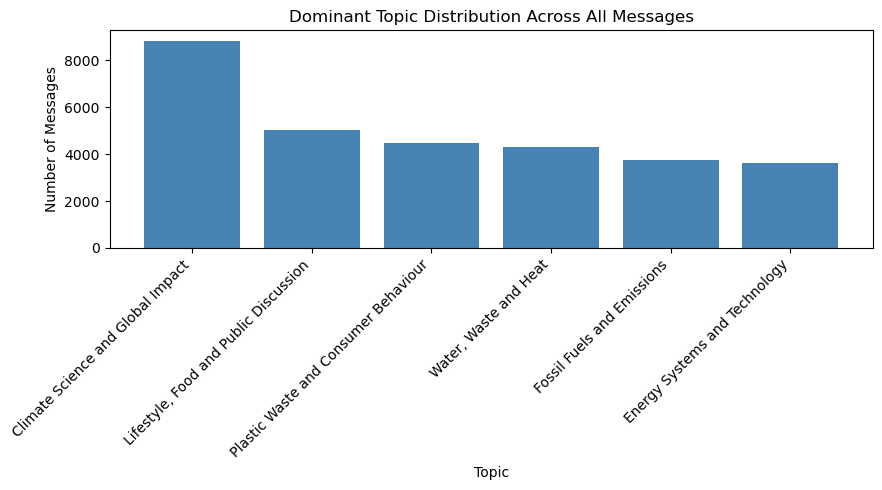

In [12]:
# ------------------------------------------------------------
# HUMAN-READABLE TOPIC LABELS
# IMPORTANT: These labels were assigned by inspecting the top words
# printed in the cell above. Re-check if you re-run on a different machine.
# ------------------------------------------------------------

topic_labels = {
    0: "Energy Systems and Technology",
    1: "Water, Waste and Heat",
    2: "Fossil Fuels and Emissions",
    3: "Plastic Waste and Consumer Behaviour",
    4: "Lifestyle, Food and Public Discussion",
    5: "Climate Science and Global Impact"
}

topic_words_table["topic_label"] = topic_words_table["topic_id"].map(topic_labels)
topic_words_table.to_csv(os.path.join(OUTPUT_DIR, "table_lda_topics_labelled.csv"), index=False)

print("Labelled LDA topics:")
safe_display(topic_words_table, n=10)

# Assign dominant topic to each message in the sampled LDA training set
topic_df["dominant_topic_id"]          = topic_distribution.argmax(axis=1)
topic_df["dominant_topic_label"]       = topic_df["dominant_topic_id"].map(topic_labels)
topic_df["dominant_topic_probability"] = topic_distribution.max(axis=1)

topic_summary = (
    topic_df["dominant_topic_label"].value_counts()
    .rename_axis("topic_label").reset_index(name="message_count")
)
topic_summary.to_csv(os.path.join(OUTPUT_DIR, "table_topic_distribution.csv"), index=False)

print("\nTopic distribution:")
safe_display(topic_summary)

# Merge topic assignments back to main df
df = df.merge(
    topic_df[["message_id", "dominant_topic_id", "dominant_topic_label", "dominant_topic_probability"]],
    on="message_id", how="left"
)

# Plot topic distribution
plt.figure(figsize=(9, 5))
plt.bar(topic_summary["topic_label"], topic_summary["message_count"], color="steelblue")
plt.title("Dominant Topic Distribution Across All Messages")
plt.xlabel("Topic")
plt.ylabel("Number of Messages")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_topic_distribution.png"), dpi=200)
plt.show()

## 12. User Interaction Network (Directed)

This section builds a directed and weighted user interaction network. Nodes represent Reddit users, and edges represent comments or replies from one user to another. The graph is directed because each interaction has a clear sender and receiver, and weighted because repeated interactions between the same users are counted.


In [13]:
# ------------------------------------------------------------
# USER INTERACTION NETWORK
# ------------------------------------------------------------

import networkx as nx

weighted_edges = (
    edges_clean.groupby(["source", "target"])
    .size().reset_index(name="weight")
    .sort_values("weight", ascending=False)
)
weighted_edges.to_csv(os.path.join(OUTPUT_DIR, "table_user_network_edges.csv"), index=False)

G_user = nx.DiGraph()
for _, row in weighted_edges.iterrows():
    G_user.add_edge(row["source"], row["target"], weight=int(row["weight"]))

# Full network statistics
wcc = list(nx.weakly_connected_components(G_user))
largest_wcc_nodes = max(wcc, key=len)
G_main = G_user.subgraph(largest_wcc_nodes).copy()
G_undirected_main = G_main.to_undirected()

print("=== Full User Interaction Network ===")
print(f"Nodes:                     {G_user.number_of_nodes():,}")
print(f"Edges:                     {G_user.number_of_edges():,}")
print(f"Density:                   {nx.density(G_user):.2e}")
print(f"Weakly connected comps:    {len(wcc):,}")
print(f"Largest WCC nodes:         {G_main.number_of_nodes():,}")
print(f"Largest WCC edges:         {G_main.number_of_edges():,}")
print(f"Avg clustering coeff:      {nx.average_clustering(G_undirected_main):.4f}")

# Note on reciprocity
reciprocity = nx.overall_reciprocity(G_user)
print(f"Reciprocity:               {reciprocity:.4f} (only {reciprocity*100:.1f}% of edges are mutual)")
print("=> Most interactions are one-directional, justifying the directed graph design.")

# Subgraph for centrality (top 2000 degree nodes — documented limitation)
if G_main.number_of_nodes() > 2000:
    keep_nodes = [
        node for node, deg in sorted(G_main.degree, key=lambda x: x[1], reverse=True)[:2000]
    ]
    G_analysis = G_main.subgraph(keep_nodes).copy()
    print(f"\nCentrality subgraph (top-2000 degree nodes): {G_analysis.number_of_nodes()} nodes, {G_analysis.number_of_edges()} edges")
    print("Limitation: centrality measures are computed on this subgraph, not the full network.")
else:
    G_analysis = G_main.copy()
    print(f"\nCentrality graph: {G_analysis.number_of_nodes()} nodes (full network used).")

=== Full User Interaction Network ===
Nodes:                     48,936
Edges:                     81,270
Density:                   3.39e-05
Weakly connected comps:    287
Largest WCC nodes:         48,149
Largest WCC edges:         80,704
Avg clustering coeff:      0.0183
Reciprocity:               0.0847 (only 8.5% of edges are mutual)
=> Most interactions are one-directional, justifying the directed graph design.

Centrality subgraph (top-2000 degree nodes): 2000 nodes, 8165 edges
Limitation: centrality measures are computed on this subgraph, not the full network.


## 13. Centrality Analysis: PageRank and Approximate Bridge Score

PageRank is used to identify influential users who receive attention from other important users. An approximate bridge score is used instead of exact betweenness centrality because exact betweenness is computationally expensive on a large network. The bridge score estimates which users appear to connect different parts of the discussion network.


In [14]:
# ------------------------------------------------------------
# CENTRALITY ANALYSIS: PAGERANK + APPROXIMATE BRIDGE SCORE
# Exact betweenness is computationally expensive on a large network, so bridge position is estimated using sampled shortest paths.
# ------------------------------------------------------------

pagerank_scores = nx.pagerank(G_analysis, weight="weight")

in_degree_weighted = dict(G_analysis.in_degree(weight="weight"))
out_degree_weighted = dict(G_analysis.out_degree(weight="weight"))
degree_centrality = nx.degree_centrality(G_analysis)

print("Computing approximate bridge score for users...")

# Convert to undirected because bridge position is easier to estimate
# using paths across the main interaction structure.
G_bridge = G_analysis.to_undirected()

all_nodes = list(G_bridge.nodes())
sample_size = min(200, len(all_nodes))

np.random.seed(RANDOM_SEED)
sample_sources = list(np.random.choice(all_nodes, size=sample_size, replace=False))

bridge_scores = {node: 0 for node in all_nodes}

for source in sample_sources:
    paths = nx.single_source_shortest_path(G_bridge, source)

    for target, path in paths.items():
        if len(path) > 2:
            for middle_node in path[1:-1]:
                bridge_scores[middle_node] += 1

max_score = max(bridge_scores.values()) if len(bridge_scores) > 0 else 0

if max_score > 0:
    for node in bridge_scores:
        bridge_scores[node] = bridge_scores[node] / max_score

print("Approximate bridge scores computed successfully.")

centrality_table = pd.DataFrame({
    "author": list(G_analysis.nodes()),
    "weighted_in_degree": [in_degree_weighted.get(node, 0) for node in G_analysis.nodes()],
    "weighted_out_degree": [out_degree_weighted.get(node, 0) for node in G_analysis.nodes()],
    "degree_centrality": [degree_centrality.get(node, 0) for node in G_analysis.nodes()],
    "pagerank": [pagerank_scores.get(node, 0) for node in G_analysis.nodes()],
    "bridge_score": [bridge_scores.get(node, 0) for node in G_analysis.nodes()]
})

centrality_table = centrality_table.sort_values("pagerank", ascending=False)

centrality_table.to_csv(
    os.path.join(OUTPUT_DIR, "table_user_centrality.csv"),
    index=False
)

print("\nTop 15 users by PageRank:")
safe_display(centrality_table.head(15))

bridge_users = centrality_table.sort_values("bridge_score", ascending=False)

print("\nTop 15 users by approximate bridge score:")
safe_display(bridge_users.head(15))

print("\nCentrality interpretation:")

top_pr = centrality_table.iloc[0]
print(
    f"Top PageRank user: {top_pr['author']} "
    f"(PageRank={top_pr['pagerank']:.4f}, "
    f"weighted in-degree={top_pr['weighted_in_degree']:.0f})"
)

print(
    "This user appears influential because many interactions point toward them, "
    "and PageRank gives extra value when those interactions come from other active users."
)

top_bridge = bridge_users.iloc[0]
print(
    f"\nTop approximate bridge user: {top_bridge['author']} "
    f"(bridge score={top_bridge['bridge_score']:.4f})"
)

print(
    "This user appears to connect different parts of the discussion network because "
    "they often appear in the middle of sampled shortest paths."
)

print("\nBridge score check:")
print("Maximum bridge score:", bridge_users["bridge_score"].max())
print("Number of users with bridge score > 0:", (bridge_users["bridge_score"] > 0).sum())

pr_rank = centrality_table.reset_index(drop=True)
pr_rank["pagerank_rank"] = range(1, len(pr_rank) + 1)
pr_rank["in_degree_rank"] = pr_rank["weighted_in_degree"].rank(ascending=False).astype(int)

different_rank_users = pr_rank[
    (pr_rank["pagerank_rank"] <= 10) &
    (pr_rank["in_degree_rank"] > 20)
].head(3)

if len(different_rank_users) > 0:
    print("\nUsers high in PageRank but not raw in-degree:")
    safe_display(
        different_rank_users[
            ["author", "pagerank_rank", "in_degree_rank", "pagerank", "weighted_in_degree"]
        ]
    )

Computing approximate bridge score for users...
Approximate bridge scores computed successfully.

Top 15 users by PageRank:


,author,weighted_in_degree,weighted_out_degree,degree_centrality,pagerank,bridge_score
615,mafco,788,224,0.227614,0.046836,1.000000
454,silence7,192,52,0.091046,0.011826,0.374217
61,Maxcactus,146,7,0.062031,0.011284,0.165232
1431,Splenda,180,92,0.108054,0.010888,0.534211
485,pnewell,90,4,0.039020,0.009918,0.185002
1003,newnemo,38,8,0.022511,0.007804,0.069369
1782,GeraldKutney,68,5,0.033517,0.006771,0.089578
770,anutensil,47,3,0.021011,0.006702,0.040779
589,Wagamaga,71,0,0.033017,0.006491,0.113301
1060,thinkB4WeSpeak,52,38,0.043022,0.005561,0.213502



Top 15 users by approximate bridge score:


,author,weighted_in_degree,weighted_out_degree,degree_centrality,pagerank,bridge_score
615,mafco,788,224,0.227614,0.046836,1.000000
1431,Splenda,180,92,0.108054,0.010888,0.534211
454,silence7,192,52,0.091046,0.011826,0.374217
843,ILikeNeurons,45,80,0.049525,0.004236,0.259710
1060,thinkB4WeSpeak,52,38,0.043022,0.005561,0.213502
485,pnewell,90,4,0.039020,0.009918,0.185002
61,Maxcactus,146,7,0.062031,0.011284,0.165232
1604,TheFerretman,40,45,0.032016,0.005520,0.162236
186,LacedVelcro,14,14,0.013507,0.002695,0.127653
739,ImLivingAmongYou,17,3,0.010005,0.002575,0.121705



Centrality interpretation:
Top PageRank user: mafco (PageRank=0.0468, weighted in-degree=788)
This user appears influential because many interactions point toward them, and PageRank gives extra value when those interactions come from other active users.

Top approximate bridge user: mafco (bridge score=1.0000)
This user appears to connect different parts of the discussion network because they often appear in the middle of sampled shortest paths.

Bridge score check:
Maximum bridge score: 1.0
Number of users with bridge score > 0: 1683

Users high in PageRank but not raw in-degree:


,author,pagerank_rank,in_degree_rank,pagerank,weighted_in_degree
5,newnemo,6,21,0.007804,38


## 14. Community Detection

This section uses greedy modularity maximisation on the undirected version of the user network. The goal is to identify clusters of users who interact more strongly with each other than with the rest of the network.


In [15]:
# ------------------------------------------------------------
# COMMUNITY DETECTION ON USER NETWORK
# ------------------------------------------------------------

from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.community.quality import modularity

G_community = G_analysis.to_undirected()

print("Running greedy modularity community detection...")
detected_communities = list(greedy_modularity_communities(G_community, weight="weight"))
community_score      = modularity(G_community, detected_communities, weight="weight")

print(f"Number of communities: {len(detected_communities)}")
print(f"Modularity score Q:    {community_score:.4f}")
print("Interpretation:", end=" ")
if community_score > 0.5:
    print("Strong community structure (Q > 0.5)")
elif community_score > 0.3:
    print("Meaningful community structure (Q > 0.3)")
else:
    print("Weak community structure (Q < 0.3)")

community_lookup = {}
for cid, members in enumerate(detected_communities):
    for member in members:
        community_lookup[member] = cid

community_size_table = (
    pd.Series(community_lookup).rename_axis("author")
    .reset_index(name="community_id")
)

community_examples = []
for cid, members in enumerate(detected_communities):
    members = list(members)
    sub_central = centrality_table[centrality_table["author"].isin(members)]                     .sort_values("pagerank", ascending=False)
    community_examples.append({
        "community_id": cid,
        "size": len(members),
        "top_pagerank_users": ", ".join(sub_central["author"].head(5).astype(str))
    })

community_summary = pd.DataFrame(community_examples).sort_values("size", ascending=False)
community_size_table.to_csv(os.path.join(OUTPUT_DIR, "table_user_community_membership.csv"), index=False)
community_summary.to_csv(os.path.join(OUTPUT_DIR, "table_user_community_summary.csv"), index=False)

print("\nLargest communities:")
safe_display(community_summary.head(10))

print("\nInterpretation:")
print("Communities contain users from multiple subreddits — users cluster by interaction")
print("patterns, not just subreddit membership. The high modularity confirms strong")
print("clustering patterns, suggesting users tend to interact more within their own groups")
print("than across groups. Bridge users may help connect these clusters.")

Running greedy modularity community detection...
Number of communities: 80
Modularity score Q:    0.5118
Interpretation: Strong community structure (Q > 0.5)

Largest communities:


,community_id,size,top_pagerank_users
0,0,498,"pnewell, newnemo, anutensil, Wagamaga, thinkB4..."
1,1,399,"mafco, Maxcactus, TheFerretman, duke_of_alinor..."
2,2,330,"silence7, Splenda, GeraldKutney, ILikeNeurons,..."
3,3,316,"Infinite-Mud3931, boppinmule, antihostile, Mol..."
4,4,233,"ImLivingAmongYou, wowhahafuck, koolspaz2, acon..."
5,5,124,"YoanB, exprtcar, thespaceageisnow, Falom, Friv..."
6,6,7,"drewiepoodle, sustainablesa, evil_burrito, sps..."
7,7,4,"sumoraiden, Allardtia, Snow_Unity, notscientific"
8,8,4,"DaisySteak, fredfreddy4444, Chinacat_Sunflower..."
9,9,3,"XXmynameisNeganXX, Legitimate_Page, KingOfAnarchy"



Interpretation:
Communities contain users from multiple subreddits — users cluster by interaction
patterns, not just subreddit membership. The high modularity confirms strong
clustering patterns, suggesting users tend to interact more within their own groups
than across groups. Bridge users may help connect these clusters.


## 15. Network Visualisation

This section visualises the most important parts of the user interaction network and centrality results. The plots are used to support the report discussion, not to replace the numerical network analysis.


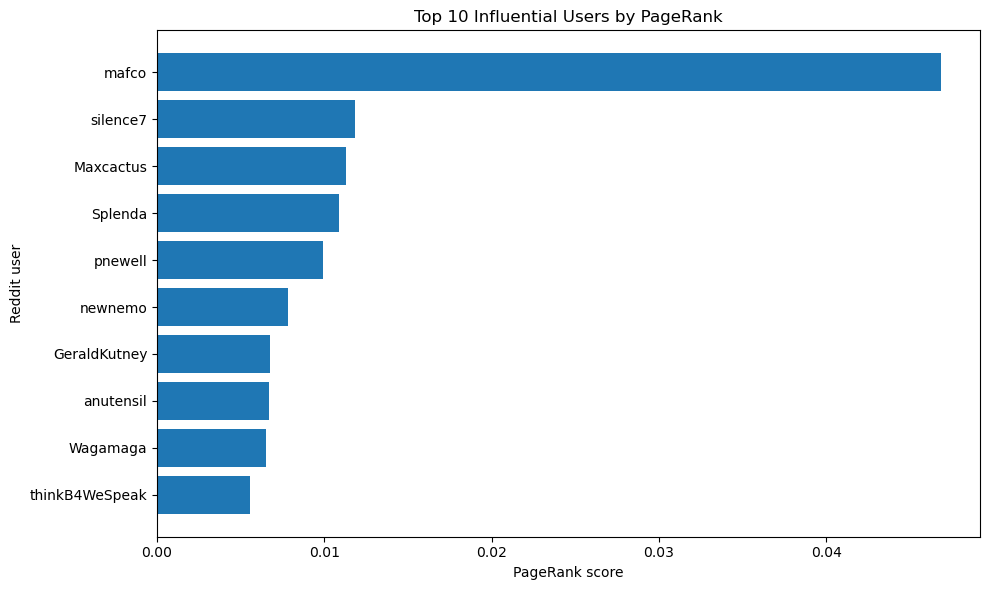

Top PageRank users plot saved.


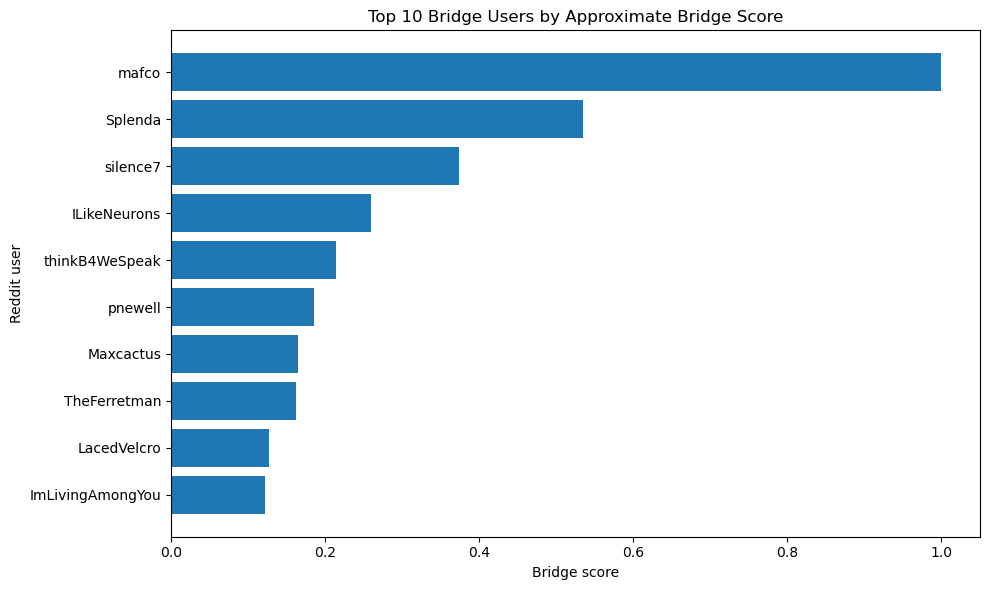

Top bridge users plot saved.


In [16]:
# ------------------------------------------------------------
# USER INFLUENCE VISUALISATION - CLEAN BAR CHART
# ------------------------------------------------------------

top_influencers = (
    centrality_table
    .sort_values("pagerank", ascending=False)
    .head(10)
    .copy()
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_influencers["author"],
    top_influencers["pagerank"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Influential Users by PageRank")
plt.xlabel("PageRank score")
plt.ylabel("Reddit user")

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "plot_top_pagerank_users.png"),
    dpi=220,
    bbox_inches="tight"
)

plt.show()

print("Top PageRank users plot saved.")



# ------------------------------------------------------------
# BRIDGE USER VISUALISATION - CLEAN BAR CHART
# ------------------------------------------------------------

top_bridges = (
    centrality_table
    .sort_values("bridge_score", ascending=False)
    .head(10)
    .copy()
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_bridges["author"],
    top_bridges["bridge_score"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Bridge Users by Approximate Bridge Score")
plt.xlabel("Bridge score")
plt.ylabel("Reddit user")

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "plot_top_bridge_users.png"),
    dpi=220,
    bbox_inches="tight"
)

plt.show()

print("Top bridge users plot saved.")

## 16. Bipartite Subreddit–Topic Network

This section builds a bipartite network connecting subreddits to LDA topics. An edge is added when at least 15% of a subreddit’s messages are assigned to a topic, showing which thematic frames are important in each community.


=== Bipartite Subreddit-Topic Network ===
Nodes:          14 (8 subreddits + 6 topics)
Edges:          25
Is bipartite:   True
Is connected:   True


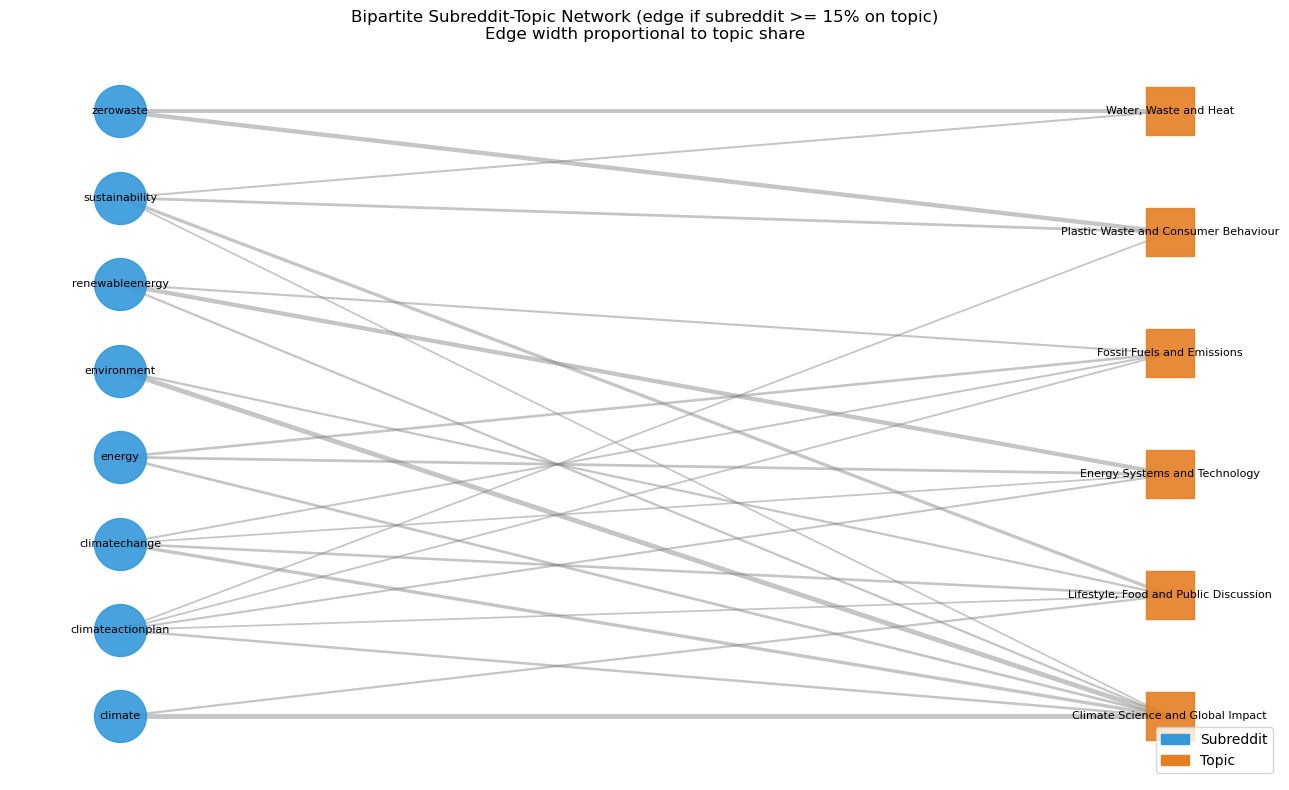


Interpretation: No subreddit is monothematic — all engage multiple frames.
Energy and renewableenergy share the Energy Systems frame.
Zerowaste and sustainability share the Plastic Waste/Lifestyle frame.


In [17]:
# ------------------------------------------------------------
# BIPARTITE SUBREDDIT-TOPIC NETWORK
# ------------------------------------------------------------

topic_subreddit = df.dropna(subset=["dominant_topic_label"]).copy()

subreddit_topic_counts = (
    topic_subreddit.groupby(["subreddit", "dominant_topic_label"])
    .size().reset_index(name="count")
)
subreddit_totals = (
    topic_subreddit.groupby("subreddit").size().reset_index(name="subreddit_total")
)
subreddit_topic_counts = subreddit_topic_counts.merge(subreddit_totals, on="subreddit", how="left")
subreddit_topic_counts["topic_share"] = (
    subreddit_topic_counts["count"] / subreddit_topic_counts["subreddit_total"]
)
subreddit_topic_counts.to_csv(os.path.join(OUTPUT_DIR, "table_subreddit_topic_distribution.csv"), index=False)

# Build bipartite graph
# Threshold: edge kept only when >= 15% of subreddit messages are assigned to that topic.
# This filters very weak topic links while retaining meaningful associations.
TOPIC_EDGE_THRESHOLD = 0.15

B_topic = nx.Graph()
for _, row in subreddit_topic_counts.iterrows():
    if row["topic_share"] >= TOPIC_EDGE_THRESHOLD:
        s_node = "sub: " + str(row["subreddit"])
        t_node = "topic: " + str(row["dominant_topic_label"])
        B_topic.add_node(s_node, node_type="subreddit")
        B_topic.add_node(t_node, node_type="topic")
        B_topic.add_edge(s_node, t_node, weight=float(row["topic_share"]))

sub_nodes   = [n for n, d in B_topic.nodes(data=True) if d.get("node_type") == "subreddit"]
topic_nodes = [n for n, d in B_topic.nodes(data=True) if d.get("node_type") == "topic"]

print("=== Bipartite Subreddit-Topic Network ===")
print(f"Nodes:          {B_topic.number_of_nodes()} ({len(sub_nodes)} subreddits + {len(topic_nodes)} topics)")
print(f"Edges:          {B_topic.number_of_edges()}")
print(f"Is bipartite:   {nx.is_bipartite(B_topic)}")
print(f"Is connected:   {nx.is_connected(B_topic)}")

import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(13, 8))
pos = {}
for i, n in enumerate(sub_nodes):   pos[n] = (0, i / max(len(sub_nodes)-1, 1))
for i, n in enumerate(topic_nodes): pos[n] = (2, i / max(len(topic_nodes)-1, 1))

edge_widths = [B_topic[u][v]["weight"] * 8 for u, v in B_topic.edges()]
nx.draw_networkx_nodes(B_topic, pos, nodelist=sub_nodes,
    node_color="#3498db", node_size=1400, alpha=0.9, ax=ax)
nx.draw_networkx_nodes(B_topic, pos, nodelist=topic_nodes,
    node_color="#e67e22", node_size=1200, node_shape="s", alpha=0.9, ax=ax)
nx.draw_networkx_edges(B_topic, pos, width=edge_widths, alpha=0.45, edge_color="grey", ax=ax)
nx.draw_networkx_labels(B_topic, pos, labels={n: n.replace("sub: ","").replace("topic: ","")
    for n in B_topic.nodes()}, font_size=8, ax=ax)

ax.legend(handles=[
    mpatches.Patch(color="#3498db", label="Subreddit"),
    mpatches.Patch(color="#e67e22", label="Topic")
], loc="lower right")
ax.set_title(f"Bipartite Subreddit-Topic Network (edge if subreddit >= {int(TOPIC_EDGE_THRESHOLD*100)}% on topic)\nEdge width proportional to topic share")
ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_subreddit_topic_network.png"), dpi=220)
plt.show()

print("\nInterpretation: No subreddit is monothematic — all engage multiple frames.")
print("Energy and renewableenergy share the Energy Systems frame.")
print("Zerowaste and sustainability share the Plastic Waste/Lifestyle frame.")

## 17. Subreddit Similarity Network

This section builds an undirected subreddit similarity network using TF-IDF cosine similarity. An edge is included when two subreddits have similarity of at least 0.50, meaning they share a strong vocabulary profile.


Top subreddit similarity pairs:


,subreddit_1,subreddit_2,cosine_similarity
19,energy,renewableenergy,0.679899
3,climate,environment,0.614251
23,environment,sustainability,0.611766
27,sustainability,zerowaste,0.610899
9,climateactionplan,environment,0.530778
1,climate,climatechange,0.493824
8,climateactionplan,energy,0.471090
14,climatechange,environment,0.466437
11,climateactionplan,sustainability,0.436245
18,energy,environment,0.425246



Subreddit similarity network (threshold=0.5):
Nodes: 8
Edges: 5

Subreddit similarity network centrality:


,subreddit,degree_centrality,bridge_score,closeness
3,environment,0.428571,1.0,0.457143
4,sustainability,0.285714,0.6,0.380952
1,renewableenergy,0.142857,0.0,0.142857
0,energy,0.142857,0.0,0.142857
2,climate,0.142857,0.0,0.285714
5,zerowaste,0.142857,0.0,0.253968
6,climateactionplan,0.142857,0.0,0.285714
7,climatechange,0.000000,0.0,0.000000


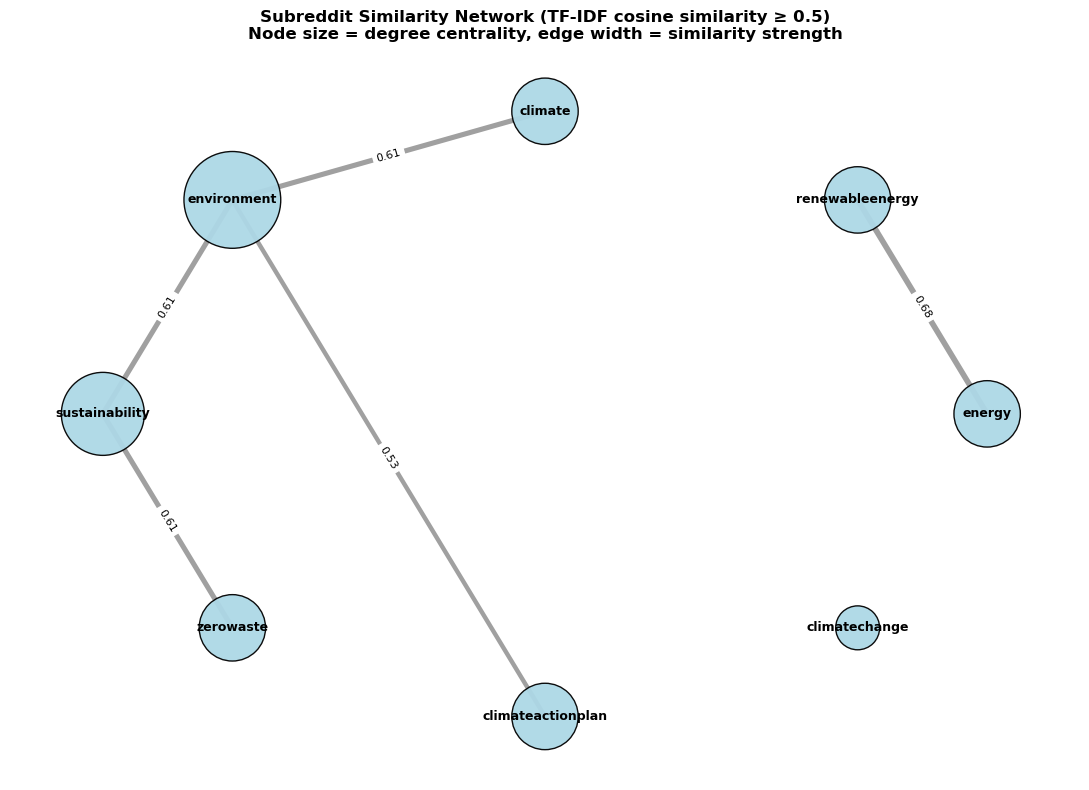


Interpretation: The subreddit similarity network shows that energy and renewableenergy are the most similar pair.
Environment also connects strongly with climate, sustainability and climateactionplan, suggesting it acts as a broad discussion space across multiple climate-related themes.


In [18]:
# ------------------------------------------------------------
# SUBREDDIT SIMILARITY NETWORK
# FIX: threshold raised from 0.15 to 0.50 for meaningful filtering
# ------------------------------------------------------------

from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix  = cosine_similarity(subreddit_matrix)
subreddit_names    = list(subreddit_docs["subreddit"])

similarity_edges = []
for i in range(len(subreddit_names)):
    for j in range(i + 1, len(subreddit_names)):
        similarity_edges.append({
            "subreddit_1": subreddit_names[i],
            "subreddit_2": subreddit_names[j],
            "cosine_similarity": round(similarity_matrix[i, j], 6)
        })

similarity_table = pd.DataFrame(similarity_edges).sort_values("cosine_similarity", ascending=False)
similarity_table.to_csv(os.path.join(OUTPUT_DIR, "table_subreddit_similarity_edges.csv"), index=False)

print("Top subreddit similarity pairs:")
safe_display(similarity_table.head(10))

# Threshold 0.50: retains genuinely similar subreddit pairs
# Previous threshold of 0.15 was too low — connected all pairs (no filtering).
SIMILARITY_THRESHOLD = 0.50

G_similarity = nx.Graph()
for _, row in similarity_table.iterrows():
    if row["cosine_similarity"] >= SIMILARITY_THRESHOLD:
        G_similarity.add_edge(row["subreddit_1"], row["subreddit_2"],
                              weight=float(row["cosine_similarity"]))

# Add isolated nodes (subreddits with no pair above threshold)
for sub in subreddit_names:
    if sub not in G_similarity:
        G_similarity.add_node(sub)

print(f"\nSubreddit similarity network (threshold={SIMILARITY_THRESHOLD}):")
print(f"Nodes: {G_similarity.number_of_nodes()}")
print(f"Edges: {G_similarity.number_of_edges()}")


# Centrality
# Degree centrality shows which subreddits have the most strong similarity links.
# Closeness centrality shows which subreddits are close to others in the similarity network.
# A small-network bridge score is estimated manually because this laptop's NetworkX version gives an error
# when calling exact betweenness centrality.

sim_deg = nx.degree_centrality(G_similarity)
sim_clo = nx.closeness_centrality(G_similarity)

# Manual bridge score for small subreddit similarity network
# A subreddit receives bridge score when it appears in the middle of shortest paths.
sim_bridge = {node: 0 for node in G_similarity.nodes()}

for source in G_similarity.nodes():
    paths_from_source = nx.single_source_shortest_path(G_similarity, source)

    for target, path in paths_from_source.items():
        if len(path) > 2:
            middle_nodes = path[1:-1]

            for middle_node in middle_nodes:
                sim_bridge[middle_node] += 1

# Normalise bridge score between 0 and 1
max_bridge = max(sim_bridge.values()) if len(sim_bridge) > 0 else 0

if max_bridge > 0:
    sim_bridge = {
        node: score / max_bridge
        for node, score in sim_bridge.items()
    }

sim_centrality = pd.DataFrame({
    "subreddit": list(G_similarity.nodes()),
    "degree_centrality": [sim_deg.get(n, 0) for n in G_similarity.nodes()],
    "bridge_score": [sim_bridge.get(n, 0) for n in G_similarity.nodes()],
    "closeness": [sim_clo.get(n, 0) for n in G_similarity.nodes()],
}).sort_values("degree_centrality", ascending=False)


print("\nSubreddit similarity network centrality:")
safe_display(sim_centrality)
sim_centrality.to_csv(os.path.join(OUTPUT_DIR, "table_subreddit_similarity_centrality.csv"), index=False)

# Visualise 

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

pos = nx.circular_layout(G_similarity)

edge_widths = [
    G_similarity[u][v]["weight"] * 6
    for u, v in G_similarity.edges()
]

node_sizes = [
    sim_deg.get(n, 0) * 9000 + 1000
    for n in G_similarity.nodes()
]

nx.draw_networkx_nodes(
    G_similarity,
    pos,
    node_size=node_sizes,
    node_color="lightblue",
    edgecolors="black",
    linewidths=1,
    alpha=0.95,
    ax=ax
)

nx.draw_networkx_edges(
    G_similarity,
    pos,
    width=edge_widths,
    edge_color="gray",
    alpha=0.75,
    ax=ax
)

nx.draw_networkx_labels(
    G_similarity,
    pos,
    font_size=9,
    font_weight="bold",
    ax=ax
)

edge_labels = {
    (u, v): f"{G_similarity[u][v]['weight']:.2f}"
    for u, v in G_similarity.edges()
}

nx.draw_networkx_edge_labels(
    G_similarity,
    pos,
    edge_labels=edge_labels,
    font_size=8,
    ax=ax
)

ax.set_title(
    f"Subreddit Similarity Network (TF-IDF cosine similarity ≥ {SIMILARITY_THRESHOLD})\n"
    "Node size = degree centrality, edge width = similarity strength",
    fontsize=12,
    fontweight="bold"
)

ax.axis("off")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "plot_subreddit_similarity_network.png"),
    dpi=220,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


print("\nInterpretation: The subreddit similarity network shows that energy and renewableenergy are the most similar pair.")
print("Environment also connects strongly with climate, sustainability and climateactionplan, suggesting it acts as a broad discussion space across multiple climate-related themes.")

## 18. Save Final Results

This section saves the cleaned dataset and generated output tables used in the final report.


In [19]:
# ------------------------------------------------------------
# SAVE FINAL CLEANED DATASET
# ------------------------------------------------------------

final_columns = [
    "post_id", "subreddit", "post_title", "message_id", "message_type",
    "author", "text", "clean_text", "timestamp", "upvotes", "parent_author",
    "word_count", "vader_compound", "sentiment_label",
    "dominant_topic_id", "dominant_topic_label", "dominant_topic_probability"
]

available_cols = [c for c in final_columns if c in df.columns]
final_path = os.path.join(OUTPUT_DIR, "reddit_climate_cleaned_with_sentiment_topics.csv")
df[available_cols].to_csv(final_path, index=False, encoding="utf-8")
print("Final cleaned dataset saved:", final_path)

Final cleaned dataset saved: assignment2_final_outputs\reddit_climate_cleaned_with_sentiment_topics.csv


## 19. Network Summary Table

This final section summarises the main networks constructed in the notebook, including their nodes, edges, direction, weights, and key analysis methods.


In [20]:
# ------------------------------------------------------------
# NETWORK SUMMARY TABLE - SAFE FINAL VERSION
# ------------------------------------------------------------

# Check whether each network exists
has_user_network = "G_user" in globals()
has_bipartite_network = "B_topic" in globals()
has_similarity_network = "G_similarity" in globals()

summary_rows = []

if has_user_network:
    summary_rows.append({
        "network": "User interaction network",
        "nodes": G_user.number_of_nodes(),
        "edges": G_user.number_of_edges(),
        "directed": "Yes",
        "weighted": "Yes",
        "meaning_of_nodes": "Reddit users",
        "meaning_of_edges": "User A commented on or replied to User B's content",
        "main_methods": "PageRank, bridge score, greedy modularity community detection"
    })
else:
    print("Warning: G_user not found. Run the user interaction network section first.")

if has_bipartite_network:
    summary_rows.append({
        "network": "Subreddit-topic bipartite network",
        "nodes": B_topic.number_of_nodes(),
        "edges": B_topic.number_of_edges(),
        "directed": "No",
        "weighted": "Yes",
        "meaning_of_nodes": "Subreddits and LDA topics",
        "meaning_of_edges": "Subreddit allocates >= 15% of messages to that topic",
        "main_methods": "Bipartite network analysis and nx.is_bipartite() verification"
    })
else:
    print("Warning: B_topic not found. Run the subreddit-topic bipartite network section first.")

if has_similarity_network:
    summary_rows.append({
        "network": "Subreddit similarity network",
        "nodes": G_similarity.number_of_nodes(),
        "edges": G_similarity.number_of_edges(),
        "directed": "No",
        "weighted": "Yes",
        "meaning_of_nodes": "Subreddits",
        "meaning_of_edges": "Cosine similarity of TF-IDF vectors >= 0.50",
        "main_methods": "TF-IDF, cosine similarity, degree centrality, bridge score and closeness centrality"
    })
else:
    print("Warning: G_similarity not found. Run the subreddit similarity network section first.")

network_summary = pd.DataFrame(summary_rows)

network_summary.to_csv(
    os.path.join(OUTPUT_DIR, "table_network_summary.csv"),
    index=False
)

print("Network summary:")
safe_display(network_summary)


print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)

print(f"Dataset:            {len(df):,} interactions, {df['subreddit'].nunique()} subreddits")

if "sentiment_label" in df.columns:
    print(f"Sentiment:          {(df['sentiment_label']=='positive').sum():,} positive / "
          f"{(df['sentiment_label']=='negative').sum():,} negative / "
          f"{(df['sentiment_label']=='neutral').sum():,} neutral")

if "kruskal_stat" in globals() and "kruskal_p" in globals():
    print(f"Kruskal-Wallis:     H={kruskal_stat:.2f}, p={kruskal_p:.2e} (significant)")

if "FINAL_TOPIC_COUNT" in globals():
    print(f"LDA topics:         k={FINAL_TOPIC_COUNT} (perplexity sweep used for checking)")

if has_user_network:
    print(f"User network:       {G_user.number_of_nodes():,} nodes, {G_user.number_of_edges():,} edges")

if "detected_communities" in globals() and "community_score" in globals():
    print(f"Communities:        {len(detected_communities)} communities, modularity Q={community_score:.4f}")

if has_bipartite_network:
    print(f"Bipartite network:  {B_topic.number_of_nodes()} nodes, {B_topic.number_of_edges()} edges, bipartite={nx.is_bipartite(B_topic)}")

if has_similarity_network:
    print(f"Similarity network: {G_similarity.number_of_nodes()} nodes, {G_similarity.number_of_edges()} edges, threshold=0.50")

if "sample_path" in globals() and "sample_size_mb" in globals():
    print(f"Sample CSV:         {sample_path} ({round(sample_size_mb, 2)} MB)")

print("="*60)
print("\nAll outputs saved to:", OUTPUT_DIR)

Network summary:


,network,nodes,edges,directed,weighted,meaning_of_nodes,meaning_of_edges,main_methods
0,User interaction network,48936,81270,Yes,Yes,Reddit users,User A commented on or replied to User B's con...,"PageRank, bridge score, greedy modularity comm..."
1,Subreddit-topic bipartite network,14,25,No,Yes,Subreddits and LDA topics,Subreddit allocates >= 15% of messages to that...,Bipartite network analysis and nx.is_bipartite...
2,Subreddit similarity network,8,5,No,Yes,Subreddits,Cosine similarity of TF-IDF vectors >= 0.50,"TF-IDF, cosine similarity, degree centrality, ..."



FINAL RESULTS SUMMARY
Dataset:            96,328 interactions, 8 subreddits
Sentiment:          44,771 positive / 31,545 negative / 20,012 neutral
Kruskal-Wallis:     H=1984.44, p=0.00e+00 (significant)
LDA topics:         k=6 (perplexity sweep used for checking)
User network:       48,936 nodes, 81,270 edges
Communities:        80 communities, modularity Q=0.5118
Bipartite network:  14 nodes, 25 edges, bipartite=True
Similarity network: 8 nodes, 5 edges, threshold=0.50
Sample CSV:         assignment2_final_outputs\reddit_climate_comments_sample_under10mb.csv (8.83 MB)

All outputs saved to: assignment2_final_outputs
